#Actividad 2
Te proponemos entonces que realices ahora la siguiente actividad con los conceptos leídos anteriormente.

Para esta actividad se ha creado un archivo usuarios_win_mac_lin.csv con datos de entrada a modo de ejemplo para clasificar si el usuario que visita un sitio web usa como sistema operativo Windows, Macintosh o Linux.

Nuestra información de entrada son 4 características que se tomó de una web que utiliza Google Analytics y son:

●      Duración de la visita en Segundos

●      Cantidad de Páginas Vistas durante la Sesión

●      Cantidad de Acciones del usuario (click, scroll, uso de checkbox, sliders,etc)

●      Suma del Valor de las acciones (cada acción lleva asociada una valoración de importancia)

Como la salida es discreta, asignaremos los siguientes valores a las etiquetas:

0 – Windows

1 – Macintosh

2 -Linux

Tu tarea es crear una Jupyter Notebook Regresion_logistica.ipynb que permita predecir qué sistema operativo utiliza un usuario según los datos de entrada.

###Importación de librerías

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

###Carga de datos

In [15]:
df_usuarios = pd.read_csv("/content/usuarios_win_mac_lin (1).csv")
df_usuarios.head()

,duracion,paginas,acciones,valor,clase
0,7.0,2,4,8,2
1,21.0,2,6,6,2
2,57.0,2,4,4,2
3,101.0,3,6,12,2
4,109.0,2,6,12,2


In [16]:
df_usuarios.columns

Index(['duracion', 'paginas', 'acciones', 'valor', 'clase'], dtype='object')

###Definición de variables

In [17]:
X = df_usuarios[['duracion', 'paginas', 'acciones', 'valor']] # Variables predictoras
y = df_usuarios['clase'] # Variable objetivo

### División de datos para entrenamiento y prueba





In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Creacion del  modelo de regresión logística y se entrena utilizando los datos de entrenamiento.

In [19]:
modelo = LogisticRegression(max_iter=1000, multi_class= 'multinomial', solver='lbfgs')
modelo.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial')

###Predicciones

In [20]:
y_pred = modelo.predict(X_test)

###Matriz de confusión

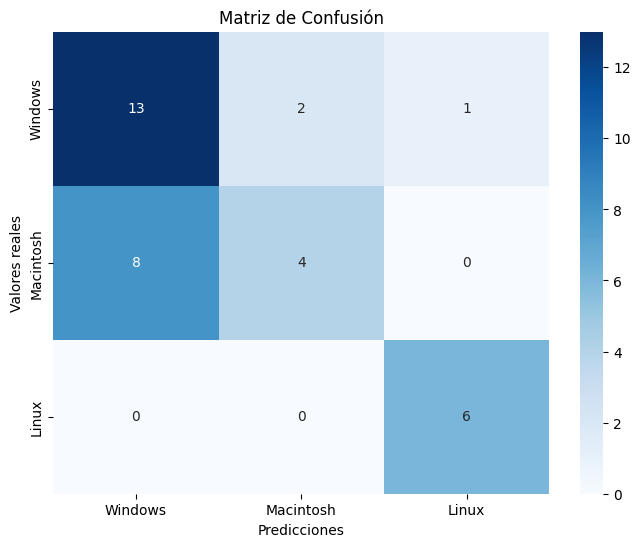

Matriz de confusión:
[[13  2  1]
 [ 8  4  0]
 [ 0  0  6]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.62      0.81      0.70        16
           1       0.67      0.33      0.44        12
           2       0.86      1.00      0.92         6

    accuracy                           0.68        34
   macro avg       0.71      0.72      0.69        34
weighted avg       0.68      0.68      0.65        34



In [21]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Windows', 'Macintosh', 'Linux'],
            yticklabels=['Windows', 'Macintosh', 'Linux'])

plt.title('Matriz de Confusión')
plt.xlabel('Predicciones')
plt.ylabel('Valores reales')
plt.show()

print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

Se utilizó un modelo de regresión logística para predecir el sistema operativo de un usuario en función de su comportamiento en el sitio web.
El modelo fue evaluado mediante una matriz de confusión y métricas de clasificación, observando un desempeño aceptable aunque limitado por el tamaño reducido del dataset.Este modelo de regresión logística alcanza una exactitud del 68%, lo que indica un desempeño aceptable en la clasificación general. Analizando por clases, el sistema operativo Windows presenta un buen recall (0.81), lo que significa que la mayoría de los usuarios de Windows son correctamente identificados, aunque su precisión (0.62) indica que también se confunden otros sistemas como Windows. En el caso de Macintosh, el modelo muestra un bajo recall (0.33), evidenciando que tiene dificultades para reconocer correctamente a estos usuarios, ya que muchos son clasificados erróneamente como Windows. Por otro lado, Linux es la clase mejor identificada, con un recall perfecto (1.00) y una alta precisión (0.86), lo que indica que el modelo reconoce todos los casos correctamente sin apenas errores. En conjunto, el modelo funciona razonablemente bien, pero presenta debilidades importantes en la clasificación de Macintosh, lo que sugiere la necesidad de mejorar los datos o el entrenamiento del modelo.
